In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Load data in Tensorflow

train_dir = r"skin_split\train"
val_dir = r"skin_split\val"
test_dir = r"skin_split\test"

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

class_names = train_ds.class_names
print("Classes: ", class_names)

Found 1044 files belonging to 5 classes.
Found 227 files belonging to 5 classes.
Found 227 files belonging to 5 classes.
Classes:  ['Acne', 'Eksim', 'Herpes', 'Panu', 'Rosacea']


In [ ]:
# Optimize the dataset pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE)

In [ ]:
# Adding Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [15]:
# Build the model

base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights = "imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 [==============================] - 1s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                         

In [16]:
# Train the model

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
33/33 [==============================] - 27s 440ms/step - loss: 1.7741 - accuracy: 0.2960 - val_loss: 1.3278 - val_accuracy: 0.4361 - lr: 0.0010
Epoch 2/20
33/33 [==============================] - 13s 377ms/step - loss: 1.2589 - accuracy: 0.4923 - val_loss: 0.9873 - val_accuracy: 0.5595 - lr: 0.0010
Epoch 3/20
33/33 [==============================] - 13s 375ms/step - loss: 1.0629 - accuracy: 0.5833 - val_loss: 0.8369 - val_accuracy: 0.6520 - lr: 0.0010
Epoch 4/20
33/33 [==============================] - 12s 361ms/step - loss: 0.9179 - accuracy: 0.6648 - val_loss: 0.7957 - val_accuracy: 0.6740 - lr: 0.0010
Epoch 5/20
33/33 [==============================] - 12s 361ms/step - loss: 0.8434 - accuracy: 0.6791 - val_loss: 0.7235 - val_accuracy: 0.7225 - lr: 0.0010
Epoch 6/20
33/33 [==============================] - 12s 359ms/step - loss: 0.8206 - accuracy: 0.6858 - val_loss: 0.6963 - val_accuracy: 0.7269 - lr: 0.0010
Epoch 7/20
33/33 [==============================] - 12s 369ms/st

In [17]:
# Fine-tune for better accuracy
# After initial training, unfreezing some top layers

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
33/33 [==============================] - 20s 405ms/step - loss: 0.5399 - accuracy: 0.7941 - val_loss: 0.4836 - val_accuracy: 0.7974 - lr: 1.0000e-05
Epoch 2/10
33/33 [==============================] - 13s 392ms/step - loss: 0.4925 - accuracy: 0.8209 - val_loss: 0.4300 - val_accuracy: 0.8326 - lr: 1.0000e-05
Epoch 3/10
33/33 [==============================] - 12s 366ms/step - loss: 0.4457 - accuracy: 0.8487 - val_loss: 0.4220 - val_accuracy: 0.8502 - lr: 1.0000e-05
Epoch 4/10
33/33 [==============================] - 12s 363ms/step - loss: 0.4609 - accuracy: 0.8448 - val_loss: 0.3987 - val_accuracy: 0.8458 - lr: 1.0000e-05
Epoch 5/10
33/33 [==============================] - 12s 361ms/step - loss: 0.4348 - accuracy: 0.8410 - val_loss: 0.3983 - val_accuracy: 0.8414 - lr: 1.0000e-05
Epoch 6/10
33/33 [==============================] - 12s 361ms/step - loss: 0.4177 - accuracy: 0.8515 - val_loss: 0.3823 - val_accuracy: 0.8414 - lr: 1.0000e-05
Epoch 7/10
33/33 [======================

8/8 [==============================] - 1s 69ms/step - loss: 0.3247 - accuracy: 0.8811
Test Accuracy:  0.8810572624206543
8/8 [==============================] - 3s 94ms/step
              precision    recall  f1-score   support

        Acne       0.89      0.89      0.89        45
       Eksim       0.77      0.87      0.82        46
      Herpes       0.91      0.93      0.92        45
        Panu       0.94      1.00      0.97        46
     Rosacea       0.91      0.71      0.80        45

    accuracy                           0.88       227
   macro avg       0.88      0.88      0.88       227
weighted avg       0.88      0.88      0.88       227



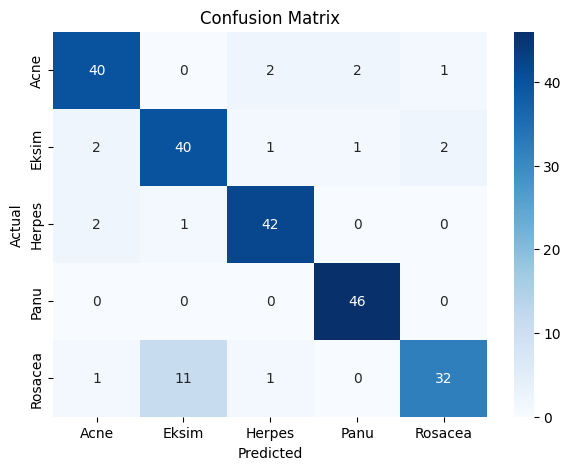

In [20]:
# Evaluation

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy: ", test_acc)

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

y_preds_probs = model.predict(test_ds)
y_preds = np.argmax(y_preds_probs, axis=1)

print(classification_report(y_true, y_preds, target_names=class_names))

cm = confusion_matrix(y_true, y_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

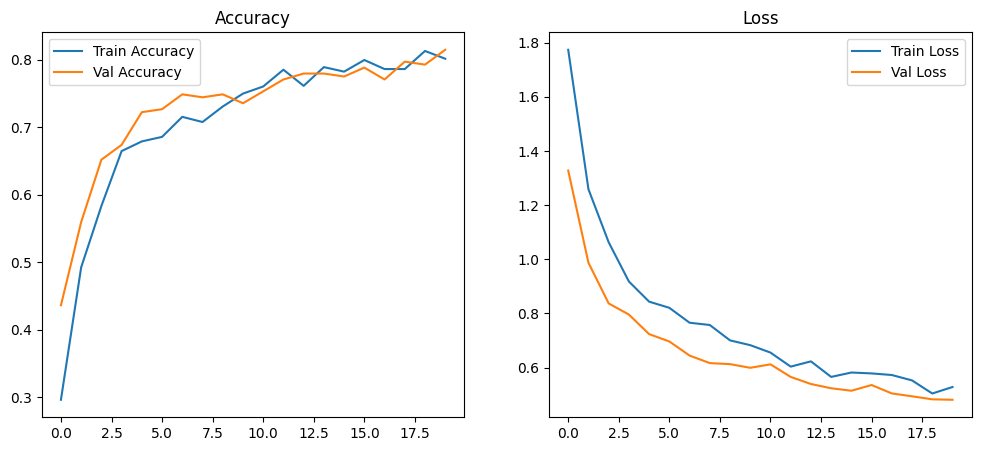

In [22]:
# Plotting Training graphs

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()